# Preprocessing of vertical PPI data

This notebook performs the analysis, preprocessing and filtering of vertical PPI ZDR data, required to compute dynamic ZDR calibration.\
It requires a file archive containing all the vertical PPI data from a campaign, which is obtained by running the **00_cfradial_netcdf_to_vaex_archive.py** script.

In [1]:
import os
import glob
import vaex
import scipy
import copy
import numpy as np
import pandas as pd
import colorcet as cc

from matplotlib import rcParams
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


*NC: this notebook was run on 03.07.2026 for final calculation of Zdr-correction for the CHOPIN campaign.*

## Loading campaigns

In [1]:
ARCHIVE_DIR = '/ltenas8/campaigns/ICEGENESIS_2021/MXPol/Zdr_calib/archives/'
campaign_name = 'ICEGENESIS_2021'

In [2]:
# ARCHIVE_DIR = '/home/clerx/MXPol/Zdr_calib'
# ARCHIVE_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib/'
ARCHIVE_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606/'
campaign_name = 'CHOPIN_2024'

In [3]:
df = vaex.open(glob.glob(os.path.join(ARCHIVE_DIR, f'dataframe_{campaign_name}*.hdf5')))

In [4]:
df

#,idx,t,r,az,zdr,zh,rhohv,snr_h,snrv
0,1.0,1732862300.0,376.95,190.09018,1.0160732,-11.859287,0.67166454,8.712797,8.588745
1,1.0,1732862300.0,376.95,194.20026,0.89881665,-10.765509,0.8649236,9.438962,9.284668
2,1.0,1732862300.0,376.95,198.52266,0.99367017,-10.705767,0.2888515,9.922291,9.548181
3,1.0,1732862300.0,376.95,202.81145,0.7325174,-9.851523,0.26310858,10.329815,10.357174
4,1.0,1732862300.0,376.95,207.11304,0.6848014,-8.911405,0.20149392,11.148286,11.185426
...,...,...,...,...,...,...,...,...,...
"23,811,798",3268.0,1737473700.0,556.95,164.05211,nan,nan,nan,nan,nan
"23,811,799",3268.0,1737473700.0,556.95,168.38113,nan,nan,nan,nan,nan
"23,811,800",3268.0,1737473700.0,556.95,172.67471,nan,nan,nan,nan,nan
"23,811,801",3268.0,1737473700.0,556.95,176.99661,-0.06707864,-20.222986,0.63224965,-3.059762,-4.4056625


In [18]:
f"{ARCHIVE_DIR}/plots/heatmap.png"

'/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606//plots/heatmap.png'

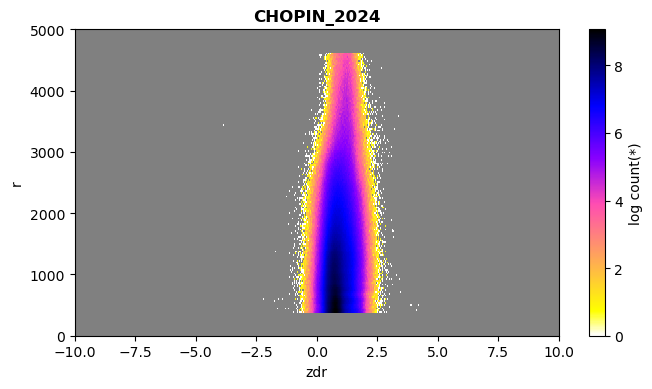

In [53]:
fig, ax = plt.subplots(1, 1, figsize=[7, 4])

un = np.unique(df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))

complete_r = np.arange(un[0], un[-1]+r_step, r_step)

df.viz.heatmap('zdr', 'r', f='log', colormap='gnuplot2_r',
                selection=['(snr_h>5) & (rhohv>0.95)'], limits='minmax',
                shape=(1000, complete_r.shape[0]))
plt.title(campaign_name, fontweight='bold')
ax.set_facecolor('gray')
plt.xlim(-10,10)
plt.ylim(0,5000)
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}plots/heatmap.png")

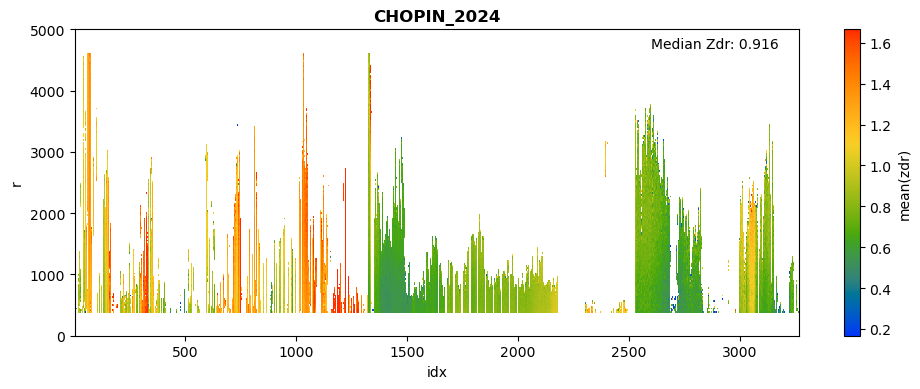

In [54]:
fig, ax = plt.subplots(1, 1, figsize=[10, 4])

un = np.unique(df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))
complete_r = np.arange(un[0], un[-1]+r_step, r_step)

med_zdr_total = np.nanmedian(df.zdr.to_numpy())
vmin = med_zdr_total - 0.75
vmax = med_zdr_total + 0.75

df.plot(df.idx, df.r, what=vaex.stat.mean(df.zdr), colormap=cc.cm.rainbow,
        #limits='minmax', 
        vmin=vmin, vmax=vmax, selection=['(snr_h>5) & (rhohv>0.95)'],
                shape=(int(df.idx.to_numpy()[-1] - df.idx.to_numpy()[0]), complete_r.shape[0]))
plt.ylim([0, 5000])
plt.title(campaign_name, fontweight='bold')
plt.annotate(f"Median Zdr: {med_zdr_total:.3f}", xy=(2600, 4700))
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}/plots/meanZdr_unfiltered.png")

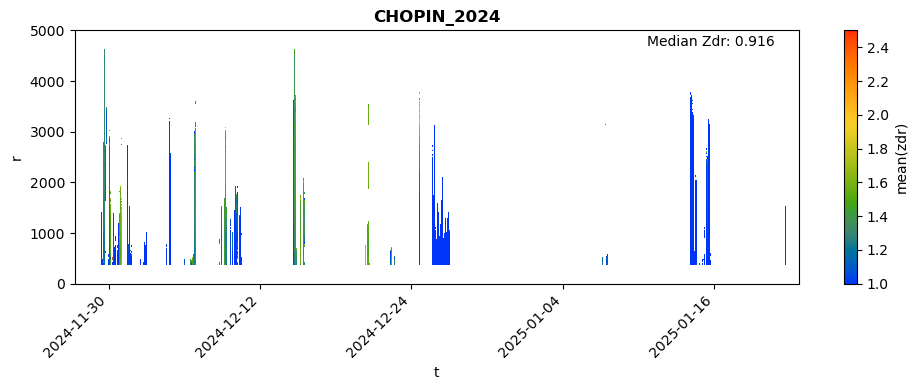

In [55]:
fig, ax = plt.subplots(1, 1, figsize=[10, 4])

un = np.unique(df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))
complete_r = np.arange(un[0], un[-1]+r_step, r_step)

med_zdr_total = np.nanmedian(df.zdr.to_numpy())
# vmin = med_zdr_total - 0.75
# vmax = med_zdr_total + 0.75
vmin = 1
vmax = 2.5


df.viz.heatmap(df.t, df.r, what=vaex.stat.mean(df.zdr), colormap=cc.cm.rainbow,
        #limits='minmax', 
        vmin=vmin, vmax=vmax, selection=['(snr_h>5) & (rhohv>0.95)'],
                shape=(int(df.idx.to_numpy()[-1] - df.idx.to_numpy()[0]), complete_r.shape[0]))
t_dt = pd.to_datetime(df.t.to_numpy(), unit='s')
start = t_dt.min() - pd.Timedelta(days=1)
end = t_dt.max() + pd.Timedelta(days=1)
start_unix = start.timestamp()
end_unix = end.timestamp()

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(pd.to_datetime(ax.get_xticks(), unit='s').strftime('%Y-%m-%d'), rotation=45, ha='right')
ax.set_xlim([start_unix, end_unix])

plt.ylim([0, 5000])
plt.title(campaign_name, fontweight='bold')
plt.annotate(f"Median Zdr: {med_zdr_total:.3f}", xy=(pd.Timestamp('2025-01-11').timestamp(), 4700))
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}/plots/meanZdr_filtered.png")

/home/clerx/micromamba/envs/vaex/lib/python3.10/site-packages/vaex/viz/mpl.py:315: UserWarning: `plot` is deprecated and it will be removed in version 5.x. Please `df.viz.heatmap` instead.
  warnings.warn('`plot` is deprecated and it will be removed in version 5.x. Please `df.viz.heatmap` instead.')


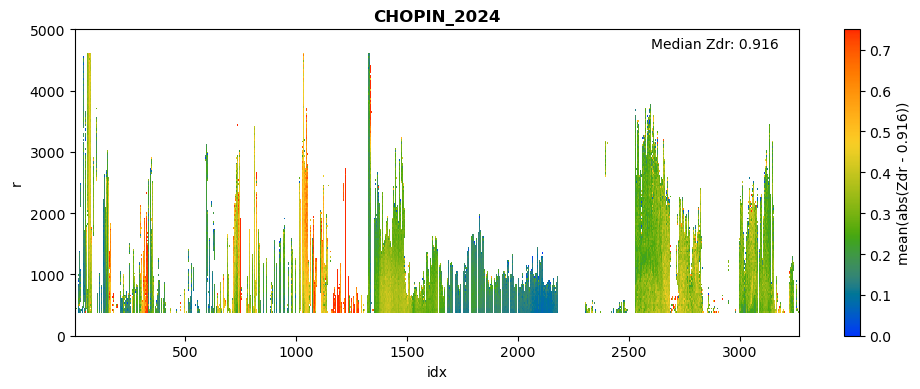

In [56]:

fig, ax = plt.subplots(1, 1, figsize=[10, 4])

un = np.unique(df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))

complete_r = np.arange(un[0], un[-1]+r_step, r_step)

med_zdr_total = np.nanmedian(df.zdr.to_numpy())
# vmin = med_zdr_total - 0.75
# vmax = med_zdr_total + 0.75
vmin = 1
vmax = 2.5

df.plot(df.idx, df.r, what=vaex.stat.mean(np.abs(df.zdr - med_zdr_total)),
                colormap=cc.cm.rainbow,
                limits='minmax', vmin=0, vmax=0.75,
                selection=['(snr_h>5) & (rhohv>0.95)'],
                shape=(int(df.idx.to_numpy()[-1] - df.idx.to_numpy()[0]), complete_r.shape[0]))
plt.title(campaign_name, fontweight='bold')
plt.ylim([0, 5000])
plt.annotate(f"Median Zdr: {med_zdr_total:.3f}", xy=(2600, 4700))

cbar = fig.axes[1]
cbar.set_ylabel(f'mean(abs(Zdr - {med_zdr_total:.3f}))')
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}/plots/medianZdr_unfiltered.png")

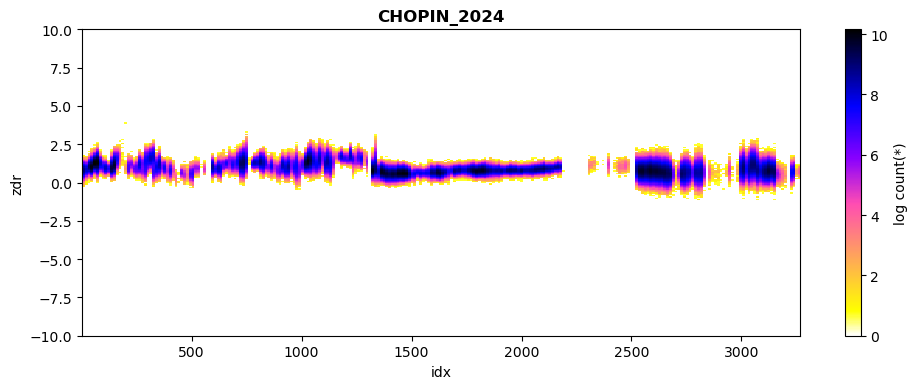

In [57]:
fig, ax = plt.subplots(1, 1, figsize=[10, 4])
df.viz.heatmap('idx', 'zdr', f='log', colormap='gnuplot2_r',
                            selection=['(snr_h>5) & (rhohv>0.95)'])

plt.title(campaign_name, fontweight='bold')
plt.ylim(-10,10)
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}/plots/heatmap_counts_unfiltered.png")

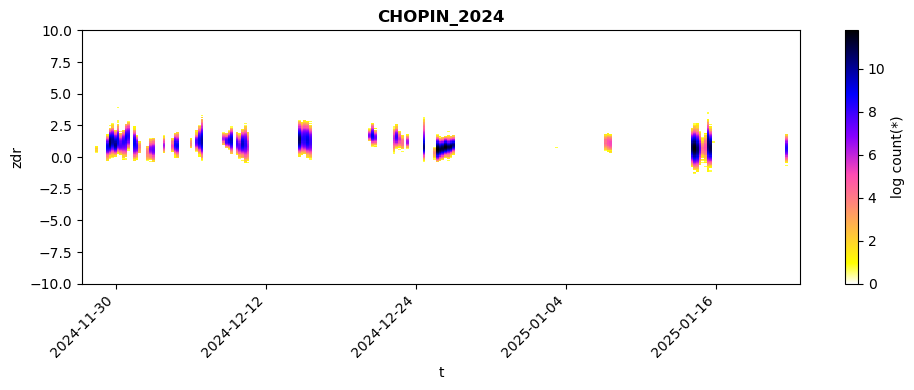

In [58]:
fig, ax = plt.subplots(1, 1, figsize=[10, 4])
df.viz.heatmap('t', 'zdr', f='log', colormap='gnuplot2_r',
                            selection=['(snr_h>5) & (rhohv>0.95)'])

t_dt = pd.to_datetime(df.t.to_numpy(), unit='s')
start = t_dt.min() - pd.Timedelta(days=1)
end = t_dt.max() + pd.Timedelta(days=1)
start_unix = start.timestamp()
end_unix = end.timestamp()

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(pd.to_datetime(ax.get_xticks(), unit='s').strftime('%Y-%m-%d'), rotation=45, ha='right')
ax.set_xlim([start_unix, end_unix])
plt.title(campaign_name, fontweight='bold')
plt.ylim(-10,10)
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}/plots/heatmap_counts_filtered.png")

## First analysis and filtering

### A look at statistics vs range
Now with median and interquartile range, instead of average and standard deviation (NOTE: this can take a long time to run)\
If these cells were already run, you can skip them and go to the next section

In [12]:
curr_df = df.dropna()
med_zdr_total = np.median(curr_df.zdr.values)

filtered_df = curr_df[(curr_df.rhohv > 0.95) & (curr_df.snr_h > 5)]

# compute bias column
filtered_df["zdr_bias"] = (filtered_df.zdr - med_zdr_total).abs()

# group by range r
grouped = filtered_df.groupby(by="r").agg({
    "count": vaex.agg.count(),
    "mean_zdr": vaex.agg.mean("zdr"),  # Mean as an approximation
    "mean_zdr_bias": vaex.agg.mean("zdr_bias"),  # Mean of the bias
    "max_zdr_bias": vaex.agg.max("zdr_bias"),  # Maximum value of bias
    "zdr_values": vaex.agg.list("zdr"),  # Collect the zdr values for later percentile calculation
    "zdr_bias_values": vaex.agg.list("zdr_bias")  # Collect the zdr_bias values for later median
})

grouped["pure_median"] = grouped.apply(lambda group: np.median(group), arguments=["zdr_values"])
grouped["bias_median"] = grouped.apply(lambda group: np.median(group), arguments=["zdr_bias_values"])
grouped["bias_q75"] = grouped.apply(lambda group: np.percentile(group, 75), arguments=["zdr_bias_values"])

grouped["pure_q75"] = grouped.apply(lambda group: np.percentile(group, 75), arguments=["zdr_values"])
grouped["pure_q25"] = grouped.apply(lambda group: np.percentile(group, 25), arguments=["zdr_values"])

# compute IQR
grouped["pure_iqr"] = grouped["pure_q75"] - grouped["pure_q25"]
grouped = grouped.sort('r')

# convert to numpy arrays
unique_r = grouped.r.values
pure_med_in_r = grouped.pure_median.values
pure_iqr_in_r = grouped.pure_iqr.values
bias_med_in_r = grouped.bias_median.values
bias_q75_in_r = grouped.bias_q75.values
bias_max_in_r = grouped.max_zdr_bias.values
count_points_per_r = grouped["count"].values

Process ForkPoolWorker-19:
Process ForkPoolWorker-4:
Process ForkPoolWorker-3:
Process ForkPoolWorker-7:
Process ForkPoolWorker-21:
Process ForkPoolWorker-26:
Process ForkPoolWorker-30:
Process ForkPoolWorker-29:
Process ForkPoolWorker-24:
Process ForkPoolWorker-23:
Process ForkPoolWorker-2:
Process ForkPoolWorker-14:
Process ForkPoolWorker-10:
Process ForkPoolWorker-13:
Process ForkPoolWorker-20:
Process ForkPoolWorker-8:
Process ForkPoolWorker-17:
Process ForkPoolWorker-31:
Process ForkPoolWorker-18:
Process ForkPoolWorker-16:
Process ForkPoolWorker-9:
Process ForkPoolWorker-12:
Process ForkPoolWorker-32:
Process ForkPoolWorker-22:
Process ForkPoolWorker-15:
Process ForkPoolWorker-28:
Process ForkPoolWorker-1:
Process ForkPoolWorker-11:
Process ForkPoolWorker-6:
Process ForkPoolWorker-27:
Process ForkPoolWorker-5:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last

In [13]:
pure_med_in_r = np.array(pure_med_in_r)
pure_iqr_in_r = np.array(pure_iqr_in_r)

bias_med_in_r = np.array(bias_med_in_r)
bias_q75_in_r = np.array(bias_q75_in_r)
bias_max_in_r = np.array(bias_max_in_r)

count_points_per_r = np.array(count_points_per_r)

stat_dic= {'unique_r':unique_r,
           'pure_med_in_r':pure_med_in_r, 'pure_iqr_in_r':pure_iqr_in_r, 
           'bias_med_in_r':bias_med_in_r, 'bias_q75_in_r':bias_q75_in_r,
           'bias_max_in_r':bias_max_in_r,
           'count_points_per_r':count_points_per_r}

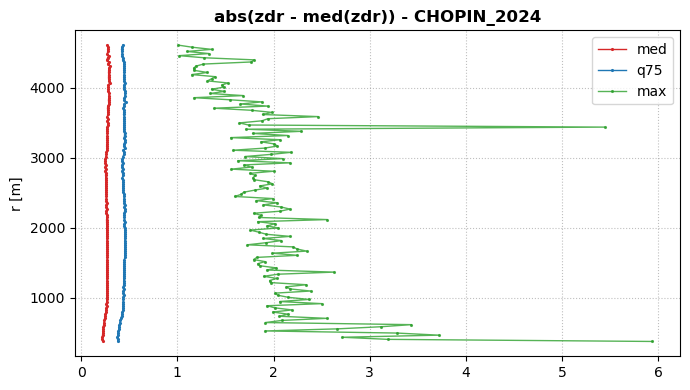

In [41]:
fig, ax = plt.subplots(1, 1, figsize=[7,4])

# Setting current axis
# Plotting
ax.plot(stat_dic['bias_med_in_r'], stat_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:red', alpha=1.,
        label='med')
ax.plot(stat_dic['bias_q75_in_r'], stat_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:blue', alpha=1.,
        label='q75')
ax.plot(stat_dic['bias_max_in_r'], stat_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:green', alpha=0.8,
        label='max')

ax.set_ylabel('r [m]')
ax.set_title(f"abs(zdr - med(zdr)) - {campaign_name}", fontweight='bold')
# ax.set_xscale('log')
ax.grid(ls=':', c='gray', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.savefig(f"{ARCHIVE_DIR}/plots/Zdr_vs_range.png")

### A look at Z_H and rho_hv

These plots are not necessary per se but can be interesting (compare with those in Alfonso's paper?)

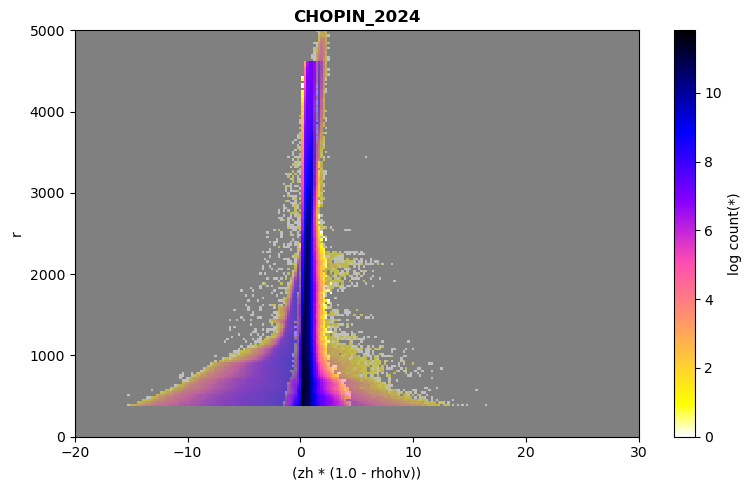

In [76]:
fig, ax = plt.subplots(1, 1, figsize=[8,5])

un = np.unique(df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))

complete_r = np.arange(un[0], un[-1]+r_step, r_step)

df.plot(df.zh*(1.-df.rhohv), df.r, f='log', colormap='gnuplot2_r',
                selection=['(snr_h>5)', '(snr_h>5) & (rhohv>0.9)'], limits='minmax',
                shape=(200, complete_r.shape[0]))
plt.title(campaign_name, fontweight='bold')
plt.xlim([-20, 30])
plt.ylim([0, 5000])
ax.set_facecolor('gray')
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}plots/Zh_(1-rhohv).png")

Fig. 1 from Alfonso's paper:

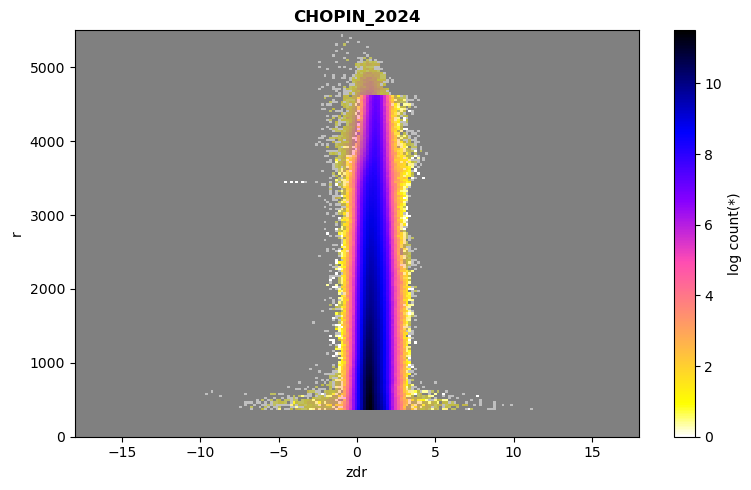

In [61]:
fig, ax = plt.subplots(1, 1, figsize=[8,5])

un = np.unique(df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))

complete_r = np.arange(un[0], un[-1]+r_step, r_step)

#curr_df.plot(curr_df.zdr, curr_df.r, f='log', colormap='Grays',
#        #selection=['(snr_h>5)', '(snr_h>5) & (rhohv>0.9)'], 
#        limits='minmax',
#        #shape=(200, complete_r.shape[0])
#       )
df.plot(df.zdr, df.r, f='log', colormap='gnuplot2_r',
        selection=['(snr_h>5)', '(snr_h>5) & (rhohv>0.9)'],
        limits=[[-18, 18], [0, 5500]],
        # shape=(72, 110)
        shape=(200, int(5500 / r_step))
       )
plt.title(campaign_name, fontweight='bold')
plt.ylim([0, 5500])
plt.xlim([-18, 18])
ax.set_facecolor('gray')
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}plots/count_vs_range.png")

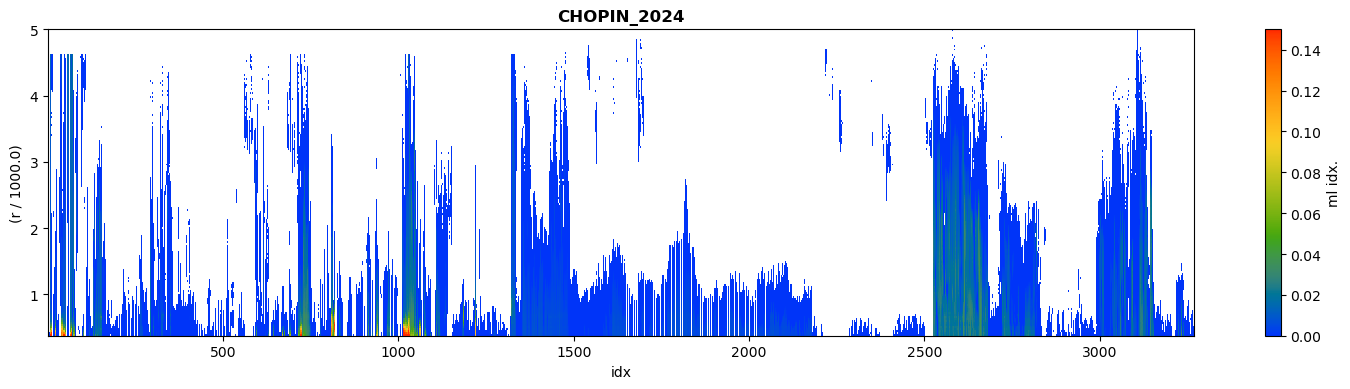

In [62]:
fig, ax = plt.subplots(1, 1, figsize=[15, 4])

un = np.unique(df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))

complete_r = np.arange(un[0], un[-1]+r_step, r_step)

df.plot(df.idx, df.r/1000.,
                what=vaex.stat.mean((df.zh-10)/50 * (1. - (df.rhohv-0.65)/0.35)),
                colormap=cc.cm.rainbow,
                colorbar_label='ml idx.', vmin=0., vmax=0.15,
                limits='minmax',
                selection=['(snr_h>5)'],
                shape=(int(df.idx.to_numpy()[-1] - df.idx.to_numpy()[0]), complete_r.shape[0]))
plt.ylim([un.min()/1000, 5])
plt.title(campaign_name, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}plots/ml_idx.png")

In [63]:
un.min(), un.max()

(376.95, 6646.95)

### Chosen threshold for ml_idx = Z_H^(norm) * (1-rho_hv^(norm))):
- ml_idx < 0.1, then we'll need to filter on the rest (and exclude gates in which at least a measurement is nan)

In [64]:
ML_IDX_MIN_ZH = 10
ML_IDX_MAX_ZH = 60
ML_IDX_NORM_ZH = ML_IDX_MAX_ZH - ML_IDX_MIN_ZH

ML_IDX_MIN_RHO = 0.65
ML_IDX_MAX_RHO = 1.
ML_IDX_NORM_RHO = ML_IDX_MAX_RHO - ML_IDX_MIN_RHO

ML_IDX_THRESHOLD = 0.1
    
curr_new_dic = {}

zh_tmp = copy.deepcopy(df.zh.to_numpy())
rho_tmp = copy.deepcopy(df.rhohv.to_numpy())

zh_tmp[zh_tmp < ML_IDX_MIN_ZH] = ML_IDX_MIN_ZH
rho_tmp[rho_tmp < ML_IDX_MIN_RHO] = ML_IDX_MIN_RHO
zh_tmp[zh_tmp > ML_IDX_MAX_ZH] = ML_IDX_MAX_ZH
rho_tmp[rho_tmp > ML_IDX_MAX_RHO] = ML_IDX_MAX_RHO

zh_norm = (zh_tmp - ML_IDX_MIN_ZH) / ML_IDX_NORM_ZH
rho_norm = (rho_tmp - ML_IDX_MIN_RHO) / ML_IDX_NORM_RHO

ml_idx = zh_norm * (1. - rho_norm)

snr_filter = np.logical_and(df.snr_h.to_numpy() > 5., df.snrv.to_numpy() > 5.)
rho_filter = df.rhohv.to_numpy() > 0.95
ml_filter = ml_idx < ML_IDX_THRESHOLD

full_filter = np.logical_and(np.logical_and(snr_filter, rho_filter), ml_filter)

for k in df.column_names:
    curr_new_dic[k] = df[k].to_numpy()[full_filter]

# Adding a field with the original number of azimuth at each scan
num_unique_az = np.full(ml_idx.shape, np.nan)
curr_az_array = df.az.to_numpy()
curr_t_array = df.t.to_numpy()
unique_t = np.unique(curr_t_array)
for i_t, curr_t in enumerate(unique_t):
    if not i_t % 1000:
        print('%d / %d' % (i_t, unique_t.shape[0]))
    valid_t = curr_t_array == curr_t
    if valid_t.shape[0]:
        num_unique_az[valid_t] = np.unique(curr_az_array[valid_t]).shape[0]
        
curr_new_dic['num_unique_az'] = num_unique_az[full_filter]

ml_filtered_df = vaex.from_dict(curr_new_dic)

0 / 3268
1000 / 3268
2000 / 3268
3000 / 3268


In [65]:
ml_filtered_df['ml_idx'] = (ml_filtered_df.zh-10)/50 * (1. - (ml_filtered_df.rhohv-0.65)/0.35)

In [66]:
ml_filtered_df
out_fpath = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606/ml_filtered_df.hdf5'
ml_filtered_df.export(out_fpath, compression='zstd')

In [67]:
ml_filtered_df


#,idx,t,r,az,zdr,zh,rhohv,snr_h,snrv,num_unique_az,ml_idx
0,1.0,1732862300.0,376.95,28.233047,0.8255568,-5.6846914,0.95274657,14.505175,14.593961,166.0,-0.04235171
1,1.0,1732862300.0,376.95,278.33746,0.53549755,-7.3654222,0.9510175,13.291761,12.563162,166.0,-0.048605785
2,1.0,1732862300.0,376.95,177.05862,0.70376617,-1.627216,0.95486945,18.86176,18.531929,166.0,-0.029985275
3,1.0,1732862300.0,406.95,170.49142,0.3985798,-4.730579,0.9529505,15.259799,14.361004,166.0,-0.03960379
4,1.0,1732862300.0,406.95,133.91441,0.61136717,-3.2154677,0.9684388,16.448757,16.144524,166.0,-0.023834025
...,...,...,...,...,...,...,...,...,...,...,...
"8,312,611",3264.0,1737467900.0,526.95,131.6166,0.7051367,5.439543,0.95676684,22.482784,22.171865,166.0,-0.011266449
"8,312,612",3264.0,1737467900.0,526.95,144.59035,0.8004609,5.6157794,0.957765,22.438103,22.604319,166.0,-0.010581001
"8,312,613",3264.0,1737467900.0,526.95,153.23903,0.6334448,5.7288737,0.9528875,22.822752,22.65261,166.0,-0.011498481
"8,312,614",3264.0,1737467900.0,526.95,161.84776,0.70255893,5.808234,0.9542663,22.756233,22.093798,166.0,-0.010954563


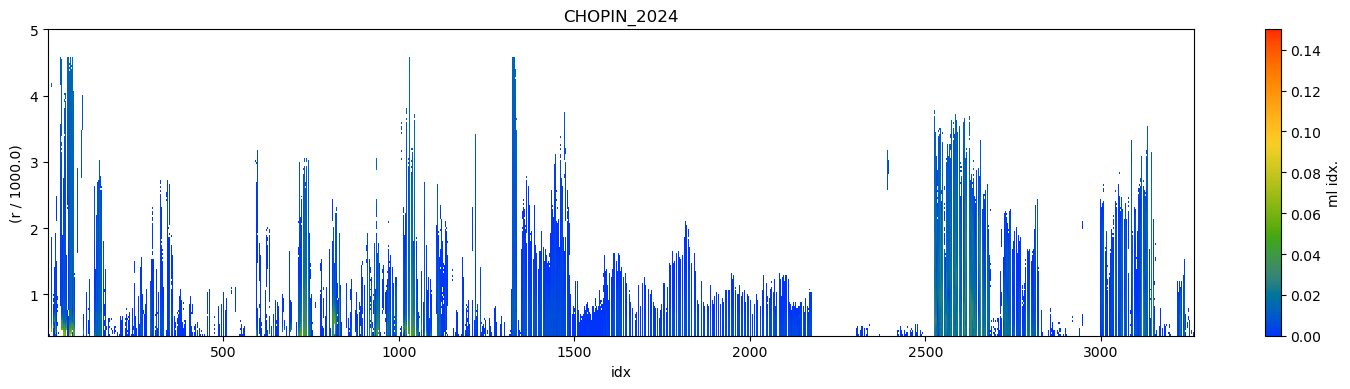

In [95]:
fig, ax = plt.subplots(1, 1, figsize=[15, 4])

un = np.unique(ml_filtered_df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))

complete_r = np.arange(un[0], un[-1]+r_step, r_step)

ml_filtered_df.plot(ml_filtered_df.idx, ml_filtered_df.r/1000.,
                what=vaex.stat.mean(ml_filtered_df.ml_idx),
                colormap=cc.cm.rainbow,
                colorbar_label='ml idx.', vmin=0., vmax=0.15,
                limits='minmax',
                selection=['(snr_h>5) & (ml_idx < 0.1)'],
                shape=(int(ml_filtered_df.idx.to_numpy()[-1] - ml_filtered_df.idx.to_numpy()[0]), complete_r.shape[0]))
plt.ylim([un.min()/1000, 5])
plt.title(campaign_name)
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}plots/ml_idx_filtered.png")

#### Removing the gates in which at least a measurement is nan

Updated 2025 (using > 10% nan as threshold criterium)

In [79]:
ml_filtered_df.shape, len(np.unique(ml_filtered_df.t.to_numpy()))

((8312616, 11), 2547)

In [80]:
curr_df = ml_filtered_df.copy()

columns_to_check = ['zh', 'zdr']
curr_t_array = curr_df.t.to_numpy()
curr_r_array = curr_df.r.to_numpy()
curr_num_az_array = curr_df.num_unique_az.to_numpy()

unique_t = np.unique(curr_t_array)
unique_r = np.unique(curr_r_array)

curr_new_dic = {}
curr_new_filter = np.zeros(curr_t_array.shape[0], dtype='bool')

for i_t, curr_t in enumerate(unique_t):
    if not i_t % 100:
        print('%d / %d' % (i_t, unique_t.shape[0]))
        
    valid_t = curr_t_array == curr_t

    if valid_t.shape[0]:
        curr_num_az = curr_num_az_array[valid_t][0] # they should be all the same
        for i_r, curr_r in enumerate(unique_r):
            valid_r = curr_r_array == curr_r
            
            if valid_r.shape[0]:
                curr_volume = np.logical_and(valid_t, valid_r)
                
                if np.sum(curr_volume) == curr_num_az:
                    nans_per_row = np.zeros(np.sum(curr_volume))
                    for col in columns_to_check:
                        col_values = curr_df[col].to_numpy()[curr_volume]
                        nans_per_row += np.isnan(col_values)

                    nan_ratio = nans_per_row / len(columns_to_check)
                    valid_rows = nan_ratio <= 0.1

                    curr_new_filter[curr_volume] = valid_rows
                        
for k in curr_df.column_names:
    curr_new_dic[k] = curr_df[k].to_numpy()[curr_new_filter]

gates_filtered_df = vaex.from_dict(curr_new_dic)

0 / 2547
100 / 2547
200 / 2547
300 / 2547
400 / 2547
500 / 2547
600 / 2547
700 / 2547
800 / 2547
900 / 2547
1000 / 2547
1100 / 2547
1200 / 2547
1300 / 2547
1400 / 2547
1500 / 2547
1600 / 2547
1700 / 2547
1800 / 2547
1900 / 2547
2000 / 2547
2100 / 2547
2200 / 2547
2300 / 2547
2400 / 2547
2500 / 2547


In [81]:
gates_filtered_df


#,idx,t,r,az,zdr,zh,rhohv,snr_h,snrv,num_unique_az,ml_idx
0,8.0,1732946800.0,556.95,190.10356,0.7788945,35.169594,0.98774236,34.17066,39.48273,166.0,0.01762965
1,8.0,1732946800.0,556.95,194.1997,0.4694358,34.293793,0.97489125,33.367195,38.586452,166.0,0.03485634
2,8.0,1732946800.0,556.95,198.48732,0.24859163,34.087826,0.9815002,33.95146,38.06017,166.0,0.025463937
3,8.0,1732946800.0,556.95,202.81609,0.72999287,34.71188,0.9850783,34.047318,40.067303,166.0,0.021071037
4,8.0,1732946800.0,556.95,207.12178,-0.09722329,33.013565,0.9742347,33.651947,38.823067,166.0,0.033882905
...,...,...,...,...,...,...,...,...,...,...,...
"784,491",3131.0,1736959200.0,1126.95,164.11333,0.7856683,13.673882,0.9823353,24.315464,23.09986,166.0,0.0037084464
"784,492",3131.0,1736959200.0,1126.95,168.39403,1.2787485,12.919959,0.97685,23.928686,23.29112,166.0,0.0038626888
"784,493",3131.0,1736959200.0,1126.95,172.71938,0.5871671,13.666603,0.9746251,24.180473,23.557247,166.0,0.0053165434
"784,494",3131.0,1736959200.0,1126.95,177.02626,0.7211405,12.64288,0.978756,23.784723,22.815935,166.0,0.0032082992


Old cell (removing gates in which more than one nan)

In [97]:
# curr_df = ml_filtered_df.copy()

# curr_t_array = curr_df.t.to_numpy()
# curr_r_array = curr_df.r.to_numpy()
# curr_num_az_array = curr_df.num_unique_az.to_numpy()

# unique_t = np.unique(curr_t_array)
# unique_r = np.unique(curr_r_array)

# curr_new_dic = {}
# curr_new_filter = np.zeros(curr_t_array.shape[0], dtype='bool')

# for i_t, curr_t in enumerate(unique_t):
#     if not i_t % 100:
#         print('%d / %d' % (i_t, unique_t.shape[0]))
        
#     valid_t = curr_t_array == curr_t

#     if valid_t.shape[0]:
#         curr_num_az = curr_num_az_array[valid_t][0] # they should be all the same
#         for i_r, curr_r in enumerate(unique_r):
#             valid_r = curr_r_array == curr_r
            
#             if valid_r.shape[0]:
#                 curr_volume = np.logical_and(valid_t, valid_r)
                
#                 if np.sum(curr_volume) == curr_num_az:
#                     curr_new_filter[curr_volume] = True
                        
# for k in curr_df.column_names:
#     curr_new_dic[k] = curr_df[k].to_numpy()[curr_new_filter]

# gates_filtered_df = vaex.from_dict(curr_new_dic)

In [99]:
gates_filtered_df['ml_idx'] = (gates_filtered_df.zh-10)/50 * (1. - (gates_filtered_df.rhohv-0.65)/0.35)

Text(0.5, 1.0, 'CHOPIN_2024')

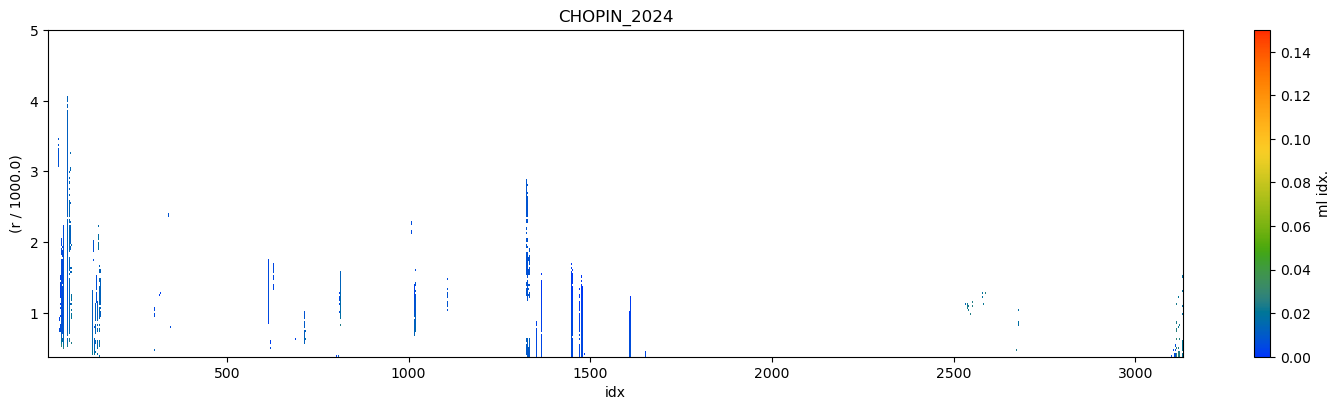

In [98]:
fig, ax = plt.subplots(1, 1, figsize=[15, 4])

un = np.unique(gates_filtered_df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))

complete_r = np.arange(un[0], un[-1]+r_step, r_step)

gates_filtered_df.plot(gates_filtered_df.idx, gates_filtered_df.r/1000.,
                what=vaex.stat.mean(gates_filtered_df.ml_idx),
                colormap=cc.cm.rainbow,
                colorbar_label='ml idx.', vmin=0., vmax=0.15,
                limits='minmax',
                selection=['(snr_h>5) & (ml_idx < 0.1)'],
                shape=(int(gates_filtered_df.idx.to_numpy()[-1] - gates_filtered_df.idx.to_numpy()[0]), complete_r.shape[0]))
plt.ylim([un.min()/1000, 5])
plt.title(campaign_name)


In [85]:
gates_filtered_df.shape[0]/filtered_df.shape[0], ml_filtered_df.shape

(0.0943720300327134, (8312616, 11))

In [100]:
mean_proxy = gates_filtered_df.mean('(abs((zh - 10)/50 * (1 - ((rhohv - 0.65)/0.35))) )')
mean_ml_idx = gates_filtered_df.mean('ml_idx', selection='(snr_h > 5) & (ml_idx < 0.1)')
print("Mean proxy value (metric1):", mean_proxy)
print("Mean ml_idx (filtered):", mean_ml_idx)

Mean proxy value (metric1): 0.00839460575500983
Mean ml_idx (filtered): 0.008330780837458753


In [87]:
# Saving filtered dataframes
if True:
    # OUT_DIR = '/home/clerx/MXPol/Zdr_calib'
    # OUT_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib'
    OUT_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606'
    if not os.path.exists(OUT_DIR):
        os.makedirs(OUT_DIR)
    out_corr_fname = f"dataframe_filtered_snr_rhohv_ml_{campaign_name}.hdf5"
    gates_filtered_df.export(os.path.join(OUT_DIR, out_corr_fname))

In [49]:
os.path.exists(os.path.join(OUT_DIR, out_corr_fname))

True

=====================
### End of the first filtering

If the first filtered dataframe was already generated, we can start from here

## Second analysis and filtering

In [88]:
if True:
    IN_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606'
    in_fname = 'dataframe_filtered_snr_rhohv_ml_%s.hdf5' % campaign_name
    gates_filtered_df = vaex.open(os.path.join(IN_DIR, in_fname))

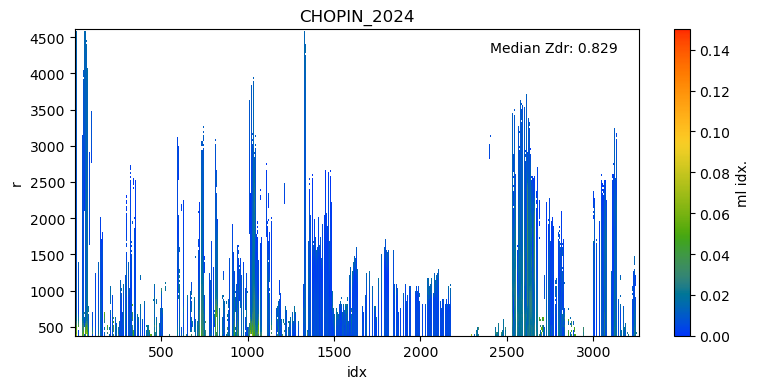

In [102]:
fig, ax = plt.subplots(1, 1, figsize=[8, 4])
curr_df = ml_filtered_df.copy() # changed wrt earlier analyses - given the large amount of dropped data blocks the gate selection doesn't 
# work/removes too much data

un = np.unique(curr_df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))

complete_r = np.arange(un[0], un[-1]+r_step, r_step)
med_zdr_total = np.nanmedian(curr_df.zdr.to_numpy())

curr_df.viz.heatmap(curr_df.idx, curr_df.r,
                what=vaex.stat.mean(np.abs(curr_df.ml_idx)),
                colormap=cc.cm.rainbow,
                colorbar_label='ml idx.', vmin=0., vmax=0.15,
                limits='minmax', selection=['(snr_h>5) & (rhohv>0.95) & (ml_idx < 0.1)'],
                shape=(int(curr_df.idx.to_numpy()[-1] - curr_df.idx.to_numpy()[0]), complete_r.shape[0]))

plt.annotate(f"Median Zdr: {med_zdr_total:.3f}", xy=(2400, 4300))
plt.title(campaign_name)
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}plots/ml_idx_filtered_check.png")

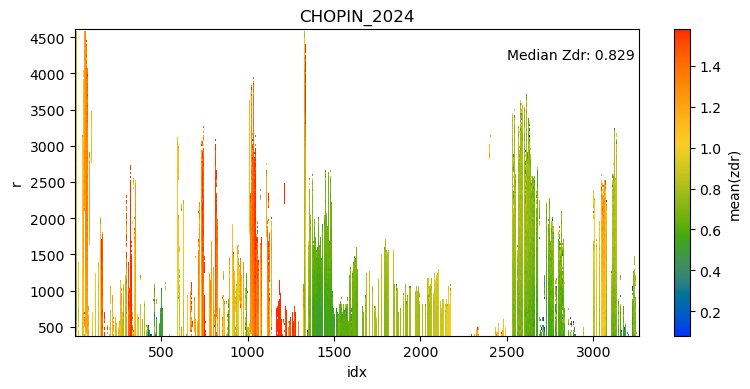

In [103]:
fig, ax = plt.subplots(1, 1, figsize=[8, 4])

un = np.unique(curr_df.r.to_numpy())
r_step = np.round(min([un[1] - un[0], un[2] - un[1]]))
complete_r = np.arange(un[0], un[-1]+r_step, r_step)

med_zdr_total = np.nanmedian(curr_df.zdr.to_numpy())
vmin = med_zdr_total - 0.75
vmax = med_zdr_total + 0.75

curr_df.viz.heatmap(curr_df.idx, curr_df.r, what=vaex.stat.mean(curr_df.zdr), colormap=cc.cm.rainbow,
                limits='minmax', vmin=vmin, vmax=vmax, selection=['(snr_h>5) & (rhohv>0.95) & (ml_idx < 0.1)'],
                shape=(int(curr_df.idx.to_numpy()[-1] - curr_df.idx.to_numpy()[0]), complete_r.shape[0]))
plt.title(campaign_name)

plt.annotate(f"Median Zdr: {med_zdr_total:.3f}", xy=(2500, 4200))
plt.tight_layout()
plt.savefig(f"{ARCHIVE_DIR}plots/meanZdr_where_ml_idx_filtered_check.png")

### A look back at the statistics after filtering

In [104]:
out_fpath = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606/ml_filtered_df.hdf5'
curr_df = vaex.open(out_fpath)
ml_filtered_df = curr_df.copy()

In [105]:
stat_post_filter_dic = {}

# Unique r entries
unique_r = np.sort(curr_df.r.unique())

# Getting limits in r
min_r = unique_r[0]
max_r = unique_r[-1]

top_half_r = max_r - (max_r - min_r)/2.
med_zdr_total = np.nanmedian(curr_df.zdr.to_numpy()[curr_df.r.to_numpy() >= top_half_r])

# Containers
pure_med_in_r = []
pure_iqr_in_r = []

bias_min_in_r = []
bias_q05_in_r = []
bias_q25_in_r = []
bias_med_in_r = []
bias_q75_in_r = []
bias_q95_in_r = []
bias_max_in_r = []

grad_bias_med_in_r = []

count_points_per_r = []

for r_i in unique_r:
    curr_range = curr_df.r.to_numpy() == r_i
    curr_valid = np.logical_and(curr_df.rhohv.to_numpy() > 0.95,
                                curr_df.snr_h.to_numpy() > 5)
    
    curr_zdr = curr_df.zdr.to_numpy()[np.logical_and(curr_range, curr_valid)]
    curr_bias = curr_zdr - med_zdr_total
    
    count_points_per_r.append(curr_zdr.shape[0])
    if curr_zdr.shape[0]:
        pure_med_in_r.append(np.nanmedian(curr_zdr))
        pure_iqr_in_r.append(np.nanquantile(curr_zdr, q=0.75) - np.nanquantile(curr_zdr, q=0.25))

        bias_min_in_r.append(np.nanmin(curr_bias))
        bias_q05_in_r.append(np.nanquantile(curr_bias, q=0.05))
        bias_q25_in_r.append(np.nanquantile(curr_bias, q=0.25))
        bias_med_in_r.append(np.nanmedian(curr_bias))
        bias_q75_in_r.append(np.nanquantile(curr_bias, q=0.75))
        bias_q95_in_r.append(np.nanquantile(curr_bias, q=0.95))
        bias_max_in_r.append(np.nanmax(curr_bias))
        
    else:
        pure_med_in_r.append(np.nan)
        pure_iqr_in_r.append(np.nan)
        
        bias_min_in_r.append(np.nan)
        bias_q05_in_r.append(np.nan)
        bias_q25_in_r.append(np.nan)
        bias_med_in_r.append(np.nan)
        bias_q75_in_r.append(np.nan)
        bias_q95_in_r.append(np.nan)
        bias_max_in_r.append(np.nan)
        
grad_bias_med_in_r = (np.roll(bias_med_in_r, -1) - np.roll(bias_med_in_r, 1)) /\
                        (np.roll(unique_r, -1) - np.roll(unique_r, 1))

pure_med_in_r = np.array(pure_med_in_r)
pure_iqr_in_r = np.array(pure_iqr_in_r)

bias_min_in_r = np.array(bias_min_in_r)
bias_q05_in_r = np.array(bias_q05_in_r)
bias_q25_in_r = np.array(bias_q25_in_r)
bias_med_in_r = np.array(bias_med_in_r)
bias_q75_in_r = np.array(bias_q75_in_r)
bias_q95_in_r = np.array(bias_q95_in_r)
bias_max_in_r = np.array(bias_max_in_r)

count_points_per_r = np.array(count_points_per_r)

stat_post_filter_dic = {'unique_r':unique_r,
                                        'pure_med_in_r':pure_med_in_r, 'pure_iqr_in_r':pure_iqr_in_r,
                                        'bias_min_in_r':bias_min_in_r, 'bias_q05_in_r':bias_q05_in_r,
                                        'bias_q25_in_r':bias_q25_in_r, 'bias_med_in_r':bias_med_in_r,
                                        'bias_q75_in_r':bias_q75_in_r, 'bias_q95_in_r':bias_q95_in_r,
                                        'bias_max_in_r':bias_max_in_r,
                                        'grad_bias_med_in_r':grad_bias_med_in_r,
                                        'count_points_per_r':count_points_per_r}

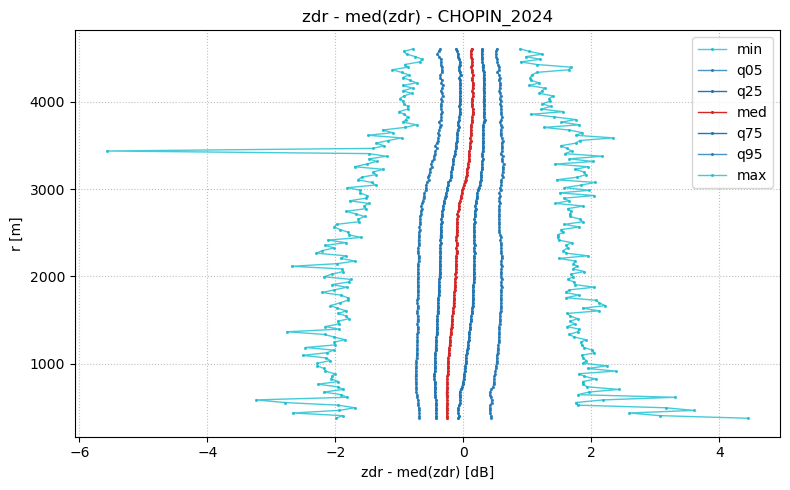

In [107]:
fig, ax = plt.subplots(1, 1, figsize=[8, 5])

logplot = False
# Setting current axis
# Plotting
ax.plot(stat_post_filter_dic['bias_min_in_r'], stat_post_filter_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:cyan', alpha=0.8,
        label='min')
ax.plot(stat_post_filter_dic['bias_q05_in_r'], stat_post_filter_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:blue', alpha=0.8,
        label='q05')
ax.plot(stat_post_filter_dic['bias_q25_in_r'], stat_post_filter_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:blue', alpha=1.,
        label='q25')
ax.plot(stat_post_filter_dic['bias_med_in_r'], stat_post_filter_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:red', alpha=1.,
        label='med')
ax.plot(stat_post_filter_dic['bias_q75_in_r'], stat_post_filter_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:blue', alpha=1.,
        label='q75')
ax.plot(stat_post_filter_dic['bias_q95_in_r'], stat_post_filter_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:blue', alpha=0.8,
        label='q95')
ax.plot(stat_post_filter_dic['bias_max_in_r'], stat_post_filter_dic['unique_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:cyan', alpha=0.8,
        label='max')

ax.set_xlabel('zdr - med(zdr) [dB]')
ax.set_ylabel('r [m]')
ax.set_title('zdr - med(zdr) - %s' % campaign_name)
if logplot:
        ax.set_xscale('symlog', linthresh=0.5)
ax.grid(ls=':', c='gray', alpha=0.5)

logleg = 'log' if logplot else 'nonlog'
plt.legend()
plt.tight_layout()
out_fig_fname = f'{ARCHIVE_DIR}/Zdr_stats_range_{logleg}_{campaign_name}.pdf'
plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')
plt.show()

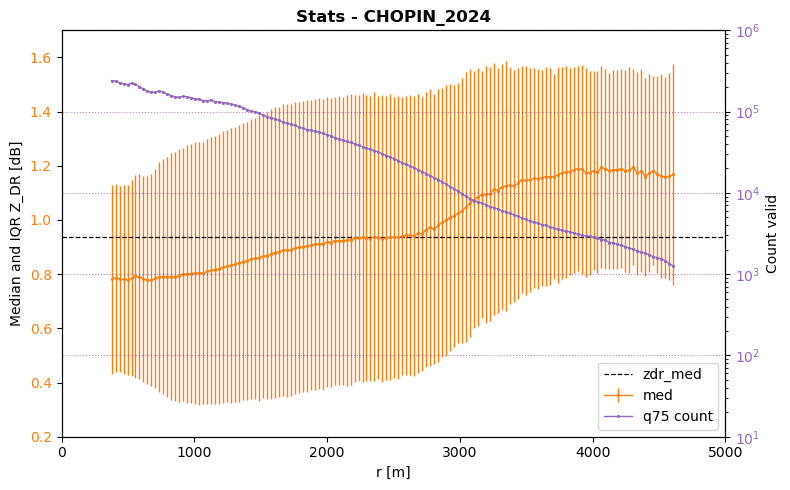

In [108]:

fig, ax = plt.subplots(1, 1, figsize=[8, 5])
# Plotting
ax.errorbar(stat_post_filter_dic['unique_r'],stat_post_filter_dic['pure_med_in_r'],
            yerr=stat_post_filter_dic['pure_iqr_in_r'],
            ls='-', lw=1., marker='.', ms=2.5, c='tab:orange', alpha=1.,
            label='med')
ax.set_xlim([0, 5000])
ax.set_xlabel('r [m]')
ax.set_title(f'Stats - {campaign_name}', fontweight='bold')
ax.set_ylim([0.2, 1.7])
ax.hlines(xmin=0, xmax=5000, y=np.nanmedian(stat_post_filter_dic['pure_med_in_r']), ls='--', lw=0.9, color='k', label='zdr_med')

# new axis for more stuff
ax2 = ax.twinx()
ax2.plot(stat_post_filter_dic['unique_r'], stat_post_filter_dic['count_points_per_r'],
        ls='-', lw=1., marker='.', ms=2.5, c='tab:purple', alpha=1.,
        label='q75 count')

ax.set_ylabel('Median and IQR Z_DR [dB]')
ax.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_ylabel('Count valid')
ax2.tick_params(axis='y', labelcolor='tab:purple')

ax2.set_yscale('log')
ax2.set_ylim(10, 1e6)
ax2.grid(ls=':', c='purple', alpha=0.5)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='lower right')
plt.tight_layout()
out_fig_fname = f'{ARCHIVE_DIR}/range_stats_{campaign_name}.pdf'
plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

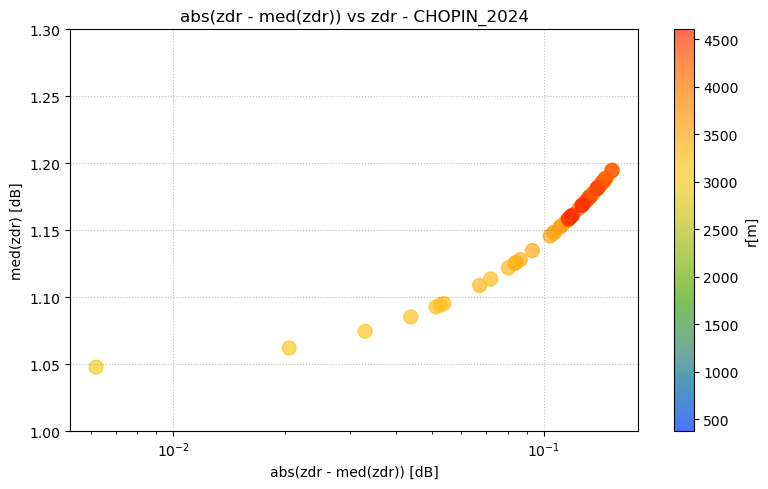

In [109]:
fig, ax = plt.subplots(1, 1, figsize=[8, 5])
# Plotting
mappable = ax.scatter(stat_post_filter_dic['bias_med_in_r'], stat_post_filter_dic['pure_med_in_r'],
                        c=stat_post_filter_dic['unique_r'], cmap=cc.cm.rainbow,
                        marker='o', s=100., alpha=0.7)

plt.sca(ax)
plt.colorbar(mappable, label='r[m]')

ax.set_xlabel('abs(zdr - med(zdr)) [dB]')
ax.set_ylabel('med(zdr) [dB]')
ax.set_title('abs(zdr - med(zdr)) vs zdr - %s' % campaign_name)
ax.set_xscale('log')
ax.grid(ls=':', c='gray', alpha=0.5)
ax.set_ylim([1, 1.3])

plt.tight_layout()

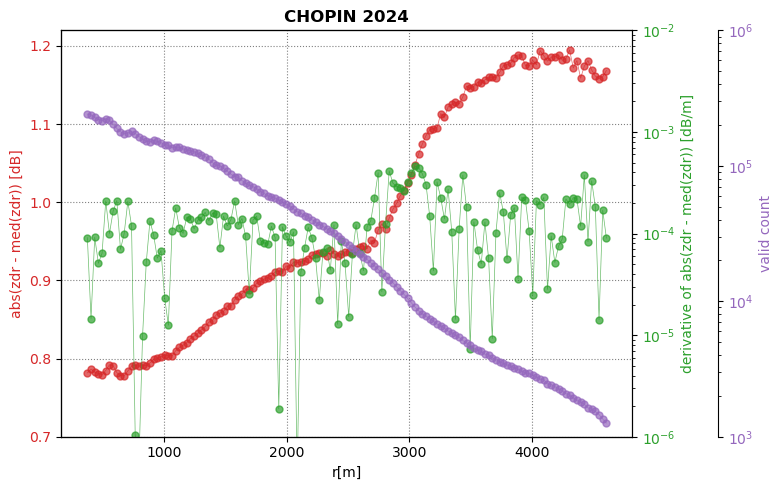

In [119]:
fig, ax = plt.subplots(1, 1, figsize=[8,5])

# Setting current axis
# Plotting
ax.plot(stat_post_filter_dic['unique_r'], np.abs(stat_post_filter_dic['pure_med_in_r']),
            c='tab:red', ls='-', lw=0.5,
            marker='.', ms=10., alpha=0.7)
ax.set_ylabel('abs(zdr - med(zdr)) [dB]', color='tab:red')
ax.set_ylim(0.7, 1.22)
ax.set_xlabel('r[m]')
ax.set_title('%s' % campaign_name.replace('_', ' '), fontweight='bold')
ax.grid(ls=':', c='gray')
ax.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax.twinx()
ax2.plot(stat_post_filter_dic['unique_r'], np.abs(stat_post_filter_dic['grad_bias_med_in_r']),
            c='tab:green',lw=0.5,
            marker='.', ms=10., alpha=0.7)

ax2.set_ylabel('derivative of abs(zdr - med(zdr)) [dB/m]', color='tab:green')
#ax2.axhline(y=1.e-3, c='tab:green', ls='--', dashes=(5,5), lw=0.8, alpha=0.8)
ax2.set_yscale('log')
#ax2.grid(ls=':', c='forestgreen', axis='y')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.set_ylim(10e-7, 10e-3)

ax3 = ax.twinx()
ax3.plot(stat_post_filter_dic['unique_r'], stat_post_filter_dic['count_points_per_r'],
            c='tab:purple', lw=0.5,
            marker='.', ms=10., alpha=0.7)
#ax3.axhline(y=10e4, c='tab:purple', ls='--', dashes=(5,5), lw=0.8, alpha=0.8)
ax3.spines["right"].set_position(("axes", 1.15))
ax3.set_ylim(10e2, 10e5)
ax3.set_ylabel('valid count', color='tab:purple')
ax3.tick_params(axis='y', labelcolor='tab:purple')
ax3.set_yscale('log')

plt.tight_layout()

out_fig_fname = f'{ARCHIVE_DIR}/all_stats_{campaign_name}.pdf'
plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

## Identification of the valid region
- min count 1000, to be significative
- derivative max 1.e-3 --> end of the TR-limiter issue in the radar (for campaigns before 2021)

In [179]:
MIN_COUNTS = 5000.
MAX_dMEDdR = 5e-4
MIN_dMEDdr = -1.8e-4
MIN_RANGE = 800.

In [180]:
def slice_at_nan(a):
    return [s for s in np.ma.clump_unmasked(np.ma.masked_invalid(a))]

In [181]:
def return_longest_section(a):
    sliced = slice_at_nan(a)
    if len(sliced):
        len_slice = []
        for curr_slice in sliced:
            len_slice.append(curr_slice.stop - curr_slice.start)
        len_slice = np.array(len_slice)
        longest_slice = sliced[np.argmax(len_slice)]
        return longest_slice
    else:
        return slice(0,0)

In [182]:
included_range = stat_post_filter_dic['unique_r'] > MIN_RANGE
included_range

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [183]:
# First we look for the gates in which the abs difference of 

included_counts = stat_post_filter_dic['count_points_per_r'] > MIN_COUNTS
included_grad = (np.abs(stat_post_filter_dic['grad_bias_med_in_r']) < MAX_dMEDdR) & (np.abs(stat_post_filter_dic['grad_bias_med_in_r']) > MIN_dMEDdr)
included_range = stat_post_filter_dic['unique_r'] > MIN_RANGE

included = np.logical_and(np.logical_and(included_counts, included_grad), included_range)
#included = included_counts

float_included = np.full(included.shape, np.nan)
float_included[included] = included[included]

longest_section_included = return_longest_section(float_included)

stat_post_filter_dic_v1 = {}

for k in stat_post_filter_dic.keys():
    if k != 'unique_r':
        tmp = np.full(stat_post_filter_dic[k].shape, np.nan)
        tmp[longest_section_included] = stat_post_filter_dic[k][longest_section_included]
        stat_post_filter_dic_v1[k] = tmp
    else:
        stat_post_filter_dic_v1[k] = stat_post_filter_dic[k]
        

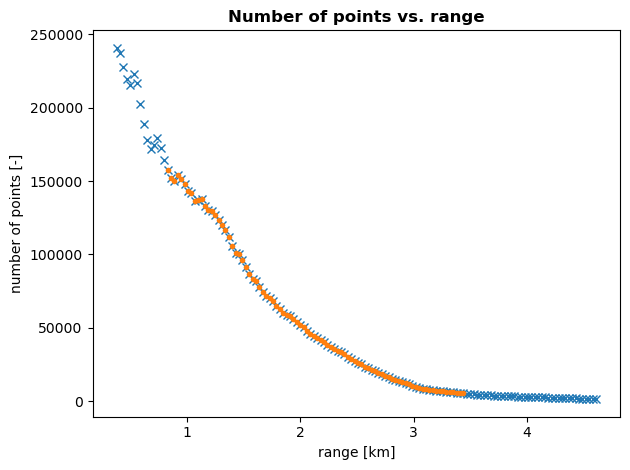

In [184]:
plt.plot(stat_post_filter_dic['unique_r']/1000, stat_post_filter_dic['count_points_per_r'], 'x', label='all')
plt.plot(stat_post_filter_dic['unique_r']/1000, stat_post_filter_dic_v1['count_points_per_r'], '.', label='selected')
plt.xlabel('range [km]')
plt.ylabel('number of points [-]')
plt.title('Number of points vs. range', fontweight='bold')
plt.tight_layout()
out_fig_fname = f'{ARCHIVE_DIR}/numpoints_range_{campaign_name}.pdf'
plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

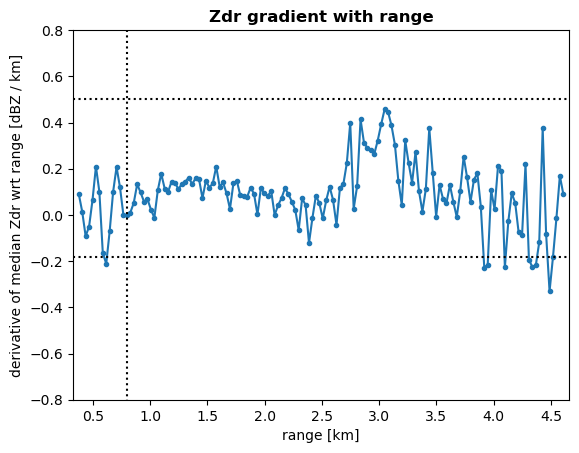

In [185]:
rmin = (stat_post_filter_dic['unique_r'].min() - 50)/1000
rmax = (stat_post_filter_dic['unique_r'].max() + 50)/1000

plt.plot(stat_post_filter_dic['unique_r']/1000, stat_post_filter_dic['grad_bias_med_in_r']*1000, '.-')
#plt.plot(stat_post_filter_dic['grad_bias_med_in_r'][included], '.', color='r')
plt.hlines(xmin=rmin, xmax=rmax, y=MAX_dMEDdR*1000, linestyles=':', color='k', lw=1.5)
plt.hlines(xmin=rmin, xmax=rmax, y=MIN_dMEDdr*1000, linestyles=':', color='k', lw=1.5)
plt.vlines(x=MIN_RANGE/1000, ymin=-1, ymax=1, linestyles=':', color='k', lw=1.5)
plt.xlim([rmin, rmax])
plt.ylim([-0.8, 0.8])
plt.xlabel('range [km]')
plt.ylabel('derivative of median Zdr wrt range [dBZ / km]')
plt.title('Zdr gradient with range', fontweight='bold')
out_fig_fname = f'{ARCHIVE_DIR}/Zdr_gradient_range_{campaign_name}.pdf'
plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

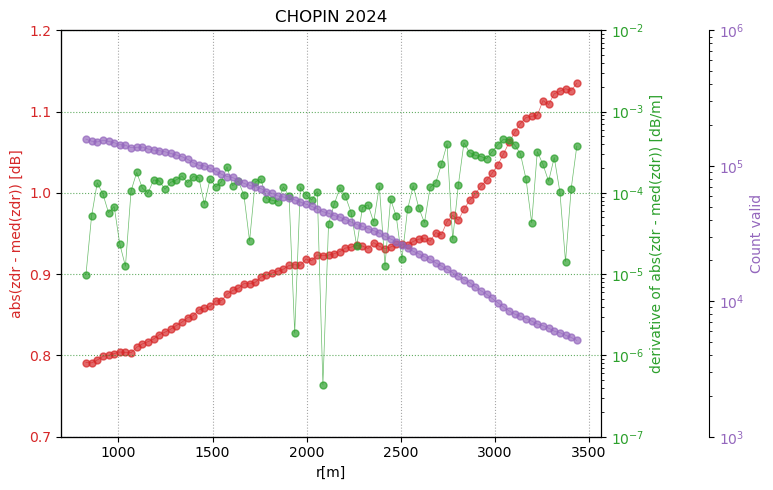

In [186]:
fig, ax = plt.subplots(1, 1, figsize=[8,5])

# Setting current axis
# Plotting
ax.plot(stat_post_filter_dic_v1['unique_r'], np.abs(stat_post_filter_dic_v1['pure_med_in_r']),
            c='tab:red', ls='-', lw=0.5,
            marker='.', ms=10., alpha=0.7)
ax.set_xlabel('r[m]')
ax.set_title('%s' % campaign_name.replace('_', ' '))
ax.grid(ls=':', c='gray', alpha=0.7, axis='x')
ax.tick_params(axis='y', labelcolor='tab:red')
ax.set_ylabel('abs(zdr - med(zdr)) [dB]', color='tab:red')
ax.set_ylim(0.7, 1.2)


ax2 = ax.twinx()
ax2.plot(stat_post_filter_dic_v1['unique_r'], np.abs(stat_post_filter_dic_v1['grad_bias_med_in_r']),
            c='tab:green',lw=0.5,
            marker='.', ms=10., alpha=0.7)

ax2.set_ylabel('derivative of abs(zdr - med(zdr)) [dB/m]', color='tab:green')

ax3 = ax.twinx()
ax3.plot(stat_post_filter_dic_v1['unique_r'], stat_post_filter_dic_v1['count_points_per_r'],
            c='tab:purple', lw=0.5,
            marker='.', ms=10., alpha=0.7)
ax3.axhline(y=1.e3, c='tab:purple', ls='--', lw=0.8, alpha=0.8)


ax2.set_yscale('log')
ax2.grid(ls=':', c='forestgreen', alpha=0.7, axis='y')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.set_ylim(10e-8, 10e-3)

ax3.spines["right"].set_position(("axes", 1.2))
ax3.set_ylabel('Count valid', color='tab:purple')
ax3.tick_params(axis='y', labelcolor='tab:purple')
ax3.set_yscale('log')
ax3.set_ylim(10e2, 10e5)


plt.tight_layout()

out_fig_fname = f"{ARCHIVE_DIR}/chosen_region_stats_{campaign_name}.pdf"
plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf',
        orientation='portrait')

In [187]:
np.nanmean(np.abs(stat_post_filter_dic_v1['pure_med_in_r']))

0.9303026517683809

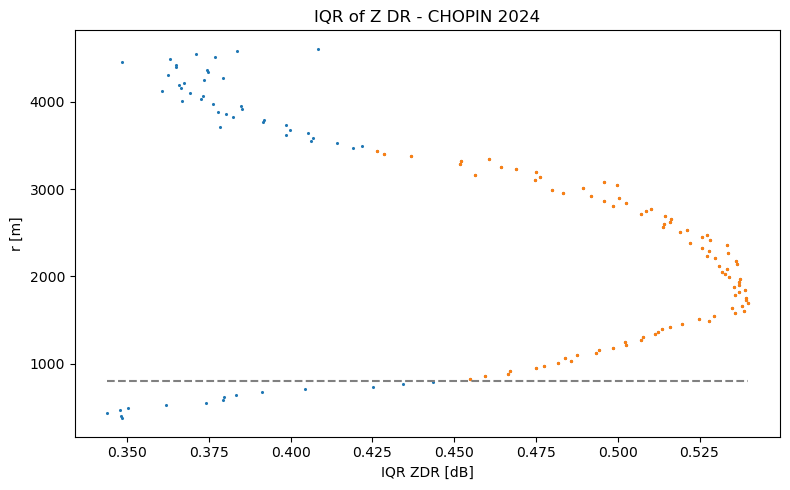

In [188]:
fig, ax = plt.subplots(1, 1, figsize=[8, 5])

# Plotting
ax.scatter(stat_post_filter_dic['pure_iqr_in_r'], stat_post_filter_dic['unique_r'], s=1.5)
ax.scatter(stat_post_filter_dic_v1['pure_iqr_in_r'], stat_post_filter_dic_v1['unique_r'], s=2.)
# Formatting
#ax.set_xscale('log')
ax.set_xlabel('IQR ZDR [dB]')
ax.set_ylabel('r [m]')
ax.set_title('IQR of Z DR - %s' % campaign_name.replace('_', ' '))
ax.hlines(xmin=stat_post_filter_dic['pure_iqr_in_r'].min(), xmax=stat_post_filter_dic['pure_iqr_in_r'].max(), y=MIN_RANGE, linestyles='--', color='gray')

plt.tight_layout()

### Now we filter also on the difference between IQR and median IQR in top gates

We see that a filtering on the derivative alone is not enough...

So, we compute the median IQR of the ZDR distribution of upper gates (upper 50% of the gates, minimum 1km).
When the IQR is too far from that, it means that the distribution is broadening and we need to cut the area used for the correction.

In [189]:
valid_r = stat_post_filter_dic_v1['unique_r'][np.isfinite(stat_post_filter_dic_v1['pure_iqr_in_r'])]

# Limit of top 50%
r_top50 = valid_r.max() - (valid_r.max() - valid_r.min())/2.

if (valid_r.max() - r_top50) < 1000.:
    r_top50 = valid_r[-1] - 1000.

interval_top50 = stat_post_filter_dic_v1['unique_r'] >= r_top50

# Computing median IQR in ranges
med_iqr = np.nanmedian(stat_post_filter_dic_v1['pure_iqr_in_r'][interval_top50])

stat_post_filter_dic_v1['med_iqr_top50r'] = med_iqr

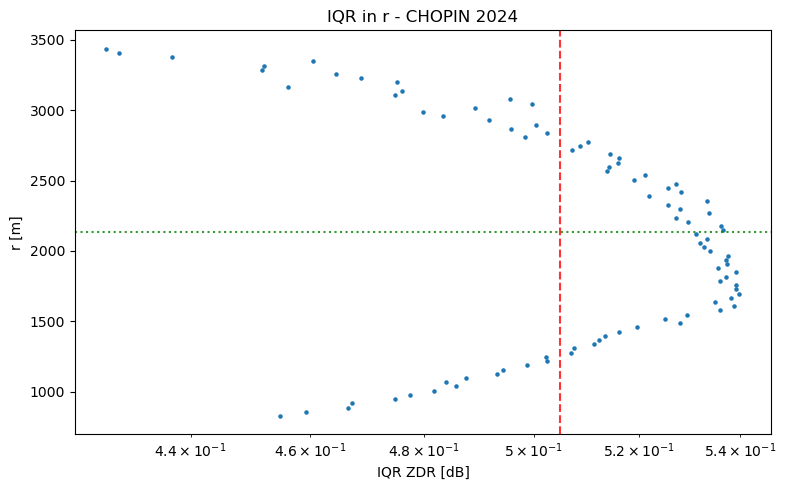

In [190]:
fig, ax = plt.subplots(1, 1, figsize=[8,5])
# Plotting
ax.scatter(stat_post_filter_dic_v1['pure_iqr_in_r'], stat_post_filter_dic_v1['unique_r'], s=5.)
# Formatting
ax.set_xscale('log')
ax.set_xlabel('IQR ZDR [dB]')
ax.set_ylabel('r [m]')
ax.set_title('IQR in r - %s' % campaign_name.replace('_', ' '))

ax.axvline(x=stat_post_filter_dic_v1['med_iqr_top50r'], ls='--', c='r', alpha=0.8)

# Plotting the gates used for the median computation
valid_r = stat_post_filter_dic_v1['unique_r'][np.isfinite(stat_post_filter_dic_v1['pure_iqr_in_r'])]
r_top50 = valid_r[-1] - (valid_r[-1] - valid_r[0])/2.
ax.axhline(r_top50, c='g', ls=':', alpha=0.8)

plt.tight_layout()

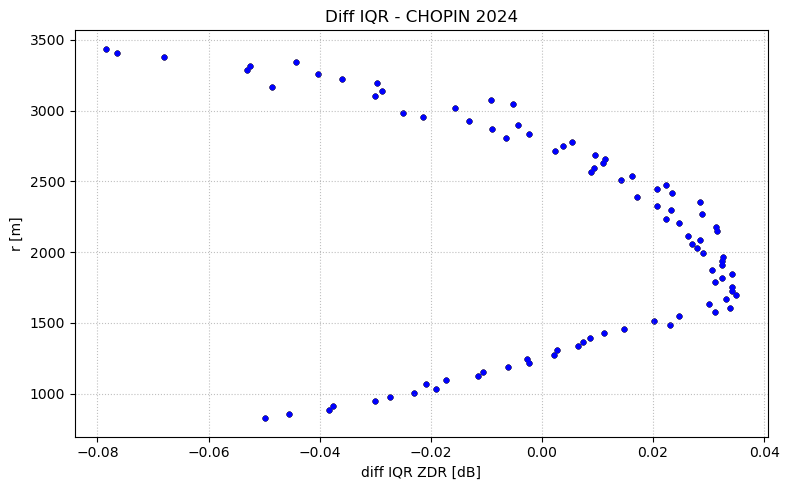

In [191]:
fig, ax = plt.subplots(1, 1, figsize=[8, 5])

# Difference between std and median in top25 gates
diff_iqr = stat_post_filter_dic_v1['pure_iqr_in_r'] - stat_post_filter_dic_v1['med_iqr_top50r']
unique_r = stat_post_filter_dic_v1['unique_r']

s0 = 10.
s1 = 10.1
s2 = 10.2
s3 = 10.3

# Plotting
ax.scatter(diff_iqr, unique_r, s=s0, c='k')
ax.scatter(diff_iqr[diff_iqr <= 0.2], unique_r[diff_iqr <= 0.2], s=s1, c='r')
ax.scatter(diff_iqr[diff_iqr <= 0.1], unique_r[diff_iqr <= 0.1], s=s2, c='g')
ax.scatter(diff_iqr[diff_iqr <= 0.05], unique_r[diff_iqr <= 0.05], s=s3, c='b')
# Formatting
#ax.set_xscale('symlog', linthresh=0.001)
ax.set_xlabel('diff IQR ZDR [dB]')
ax.set_ylabel('r [m]')
ax.set_title('Diff IQR - %s' % campaign_name.replace('_', ' '))

ax.grid(ls=':', color='gray', alpha=0.5)

#if np.nanmin(diff_iqr) < 1.e-4:
#    ax.set_xlim([1.e-4, np.nanmax(diff_iqr)*1.01])

plt.tight_layout()

### Threshold IQR: 0.2dB

In [192]:
if True:
    MAX_IQR_DIFF = 0.2

    # Defining gates eligible for computing the correction
    unique_r = stat_post_filter_dic_v1['unique_r']

    # Difference between std and median in top25 gates
    diff_iqr = np.abs(stat_post_filter_dic_v1['pure_iqr_in_r'] - stat_post_filter_dic_v1['med_iqr_top50r'])

    included = diff_iqr <= MAX_IQR_DIFF

    float_included = np.full(included.shape, np.nan)
    float_included[included] = included[included]

    logest_section_included = return_longest_section(float_included)

    r_corr = unique_r[logest_section_included]

    stat_post_filter_dic_v2 = {}

    for k in stat_post_filter_dic_v1.keys():
        if k != 'unique_r' and k != 'med_iqr_top50r':
            tmp = stat_post_filter_dic_v1[k]
            stat_post_filter_dic_v2[k] = tmp[logest_section_included]

    stat_post_filter_dic_v2['r_corr'] = r_corr
    stat_post_filter_dic_v2['med_iqr_top50r'] = stat_post_filter_dic_v1['med_iqr_top50r']

    stat_post_filter_dic_v1['r_corr'] = r_corr

In [193]:
print(np.nanmean(curr_df['zdr'].values))


0.8750804


### Applying the gates filter to the dataframe

In [194]:
r_corr

array([ 826.95001221,  856.95001221,  886.95001221,  916.95001221,
        946.95001221,  976.95001221, 1006.95001221, 1036.94995117,
       1066.94995117, 1096.94995117, 1126.94995117, 1156.94995117,
       1186.94995117, 1216.94995117, 1246.94995117, 1276.94995117,
       1306.94995117, 1336.94995117, 1366.94995117, 1396.94995117,
       1426.94995117, 1456.94995117, 1486.94995117, 1516.94995117,
       1546.94995117, 1576.94995117, 1606.94995117, 1636.94995117,
       1666.94995117, 1696.94995117, 1726.94995117, 1756.94995117,
       1786.94995117, 1816.94995117, 1846.94995117, 1876.94995117,
       1906.94995117, 1936.94995117, 1966.94995117, 1996.94995117,
       2026.94995117, 2056.94995117, 2086.94995117, 2116.94995117,
       2146.94995117, 2176.94995117, 2206.94995117, 2236.94995117,
       2266.94995117, 2296.94995117, 2326.94995117, 2356.94995117,
       2386.94995117, 2416.94995117, 2446.94995117, 2476.94995117,
       2506.94995117, 2536.94995117, 2566.94995117, 2596.94995

In [195]:
# Applying all the filters
r_corr = stat_post_filter_dic_v2['r_corr'][np.isfinite(stat_post_filter_dic_v2['bias_med_in_r'])]

curr_df = ml_filtered_df.copy()

dff = curr_df[curr_df.r == r_corr[0]]
for r in r_corr[1:]:
    dff = dff.filter(dff.r == r, mode="or")

filtered_df_dic_v2 = dff

In [196]:
med_zdr_total = np.nanmedian(dff.zdr.to_numpy())
print(med_zdr_total)
#print(np.nanmedian(stat_post_filter_dic['zdr'].to_numpy()))
print(np.nanmedian(filtered_df_dic_v2['zdr'].to_numpy()))

0.8588234
0.8588234


In [197]:
# exporting the filtered dictionary
if True:
    OUT_DIR = 'dataframes_v5'
    out_corr_fname = f'{ARCHIVE_DIR}/dataframe_filtered_v2_median_derivative_{campaign_name}.hdf5'
    filtered_df_dic_v2.export(os.path.join(ARCHIVE_DIR, out_corr_fname))

# ========

# THE END

# ========